In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from datetime import datetime

In [2]:
dataset = "impli"

sim_functions = [
    "cos",
    "cka",
    "wasser",
]

agg_functions = [
    "mean",
    "max",
    "sum",
    "entropy",
    "gini"
]


model_map = {
    "google-bert/bert-base-uncased": "BERT-base Uncased",
    "google-bert/bert-base-cased": "BERT-base Cased",
    "google-bert/bert-large-uncased": "BERT-large Uncased",
    "google-bert/bert-large-cased": "BERT-large Cased",
    "answerdotai/ModernBERT-base": "ModernBERT-base",
    "answerdotai/ModernBERT-large": "ModernBERT-large",
}

models = list(model_map.keys())

layer_map = {
    "google-bert/bert-base-uncased": list(range(12)),
    "google-bert/bert-base-cased": list(range(12)),
    "google-bert/bert-large-uncased": list(range(24)),
    "google-bert/bert-large-cased": list(range(24)),
    "answerdotai/ModernBERT-base": list(range(22)),
    "answerdotai/ModernBERT-large": list(range(28)),
}

# master file
ROOT = Path.cwd().parent

scores_dir = ROOT / "data" / "processed" 
csv_file = f"{str(scores_dir)}/impli_layers.csv"

print(csv_file)

/Users/mmi/Documents/projects/idioms_decomposability/decomp_code/idioms_decomposability/data/processed/impli_layers.csv


In [3]:
df = pd.read_csv(csv_file)

df.shape

df.columns.tolist()

['Unnamed: 0',
 'premise',
 'hypothesis',
 'extracted_idiom',
 'base_form',
 'idiom_pos',
 'idiom_processed',
 'token_scores',
 'decomp_score',
 'sim_function',
 'model_name',
 'model_label',
 'model_folder',
 'timestamp',
 'layer',
 'sim_func',
 'agg_func',
 'source_path']

## correlation: decomp vs syntax

In [ ]:
import pandas as pd
from scipy.stats import spearmanr

df_syntax = pd.read_csv("data/syntax_flexibility.csv")


column_to_merge = "premise"

merged = df.merge(
    df_syntax,
    on=column_to_merge,
    how="inner"
)

# merged.shape
merged.columns

Index(['Unnamed: 0_x', 'premise', 'hypothesis_x', 'extracted_idiom_x',
       'base_form_x', 'idiom_pos_x', 'idiom_processed', 'token_scores',
       'decomp_score', 'sim_function', 'model_name', 'model_label',
       'model_folder', 'timestamp', 'layer', 'sim_func', 'agg_func',
       'source_path', 'Unnamed: 0_y', 'hypothesis_y', 'extracted_idiom_y',
       'base_form_y', 'idiom_pos_y', 'identity_cql', 'passive_cql',
       'adj_insertion_cql_1', 'adj_insertion_cql_2', 'adv_insertion_cql',
       'adv_insertion_cql_adj', 'nominalization_cql', 'adj_insertion_full_1',
       'adj_insertion_full_2', 'adj_insertion_rel_1', 'adj_insertion_rel_2',
       'adv_insertion_full', 'adv_insertion_full_adj', 'adv_insertion_rel',
       'adv_insertion_rel_adj', 'identity_full', 'identity_rel',
       'nominalization_full', 'nominalization_rel', 'passive_full',
       'passive_rel', 'entropy_full', 'entropy_rel'],
      dtype='object')

In [5]:
def run_correlation_df(
    df,
    x_col="entropy_full",
    y_col="decomp_score"
):
    # drop NaNs just in case
    sub = df[[x_col, y_col]].dropna()

    if len(sub) < 3:
        return None

    corr, p_value = spearmanr(sub[x_col], sub[y_col])

    return {
        "spearmanr": corr,
        "p_value": p_value,
        "n": len(sub),
    }


In [6]:
group_cols = [
    "model_name",
    "layer",
    "sim_func",
    "agg_func",
    "timestamp",
]

results = []

for keys, group in merged.groupby(group_cols):
    stats = run_correlation_df(group)

    if stats is None:
        continue

    record = dict(zip(group_cols, keys))
    record.update(stats)
    results.append(record)

corr_df = pd.DataFrame(results)
corr_df.head()




,model_name,layer,sim_func,agg_func,timestamp,spearmanr,p_value,n
0,answerdotai/ModernBERT-base,0,cka,entropy,2025-12-25_02:34:31,-0.084239,0.053277,527
1,answerdotai/ModernBERT-base,0,cka,gini,2025-12-25_02:34:31,-0.043902,0.314456,527
2,answerdotai/ModernBERT-base,0,cka,max,2025-12-25_02:34:31,-0.009581,0.826316,527
3,answerdotai/ModernBERT-base,0,cka,mean,2025-12-25_02:34:31,0.000230,0.995805,527
4,answerdotai/ModernBERT-base,0,cka,sum,2025-12-25_02:34:31,-0.022684,0.603364,527


In [ ]:
corr_df.to_csv(f"data/impli_layer_correlation.csv")

### significant only

In [31]:
sig = corr_df[corr_df["p_value"] < 0.05]

print(sig.shape)
sig.head()

(443, 8)


,model_name,layer,sim_func,agg_func,timestamp,spearmanr,p_value,n
11,answerdotai/ModernBERT-base,0,wasser,gini,2025-12-25_02:34:31,-0.134499,0.001972,527
15,answerdotai/ModernBERT-base,1,cka,entropy,2025-12-25_02:34:31,-0.095315,0.028678,527
25,answerdotai/ModernBERT-base,1,wasser,entropy,2025-12-25_02:34:31,-0.098226,0.024132,527
26,answerdotai/ModernBERT-base,1,wasser,gini,2025-12-25_02:34:31,-0.121115,0.005369,527
30,answerdotai/ModernBERT-base,2,cka,entropy,2025-12-25_02:34:31,-0.090483,0.037847,527


In [39]:
sig = sig.sort_values(by="spearmanr")

print(sig.shape)

sig.head(10)

(443, 8)


,model_name,layer,sim_func,agg_func,timestamp,spearmanr,p_value,n
311,answerdotai/ModernBERT-base,20,wasser,gini,2025-12-25_02:34:31,-0.161356,0.000199,527
1661,google-bert/bert-large-uncased,12,wasser,gini,2025-12-25_02:34:13,-0.144657,0.000867,527
1436,google-bert/bert-large-cased,21,wasser,gini,2025-12-25_02:34:13,-0.141850,0.001094,527
854,google-bert/bert-base-cased,6,wasser,sum,2025-12-25_02:34:13,-0.139946,0.001278,527
1706,google-bert/bert-large-uncased,15,wasser,gini,2025-12-25_02:34:13,-0.139756,0.001298,527
1166,google-bert/bert-large-cased,3,wasser,gini,2025-12-25_02:34:13,-0.134828,0.001922,527
836,google-bert/bert-base-cased,5,wasser,gini,2025-12-25_02:34:13,-0.134793,0.001927,527
11,answerdotai/ModernBERT-base,0,wasser,gini,2025-12-25_02:34:31,-0.134499,0.001972,527
881,google-bert/bert-base-cased,8,wasser,gini,2025-12-25_02:34:13,-0.134467,0.001977,527
1051,google-bert/bert-base-uncased,8,cka,gini,2025-12-25_02:34:13,-0.133360,0.002155,527


### layer counts


In [34]:
sig["layer"].value_counts()

layer
1     30
9     28
2     26
3     25
7     25
6     23
0     23
8     23
10    23
5     22
4     22
11    20
15    17
12    15
20    14
14    12
19    12
13    12
17    11
16    11
22    10
23    10
18     8
21     8
26     5
27     4
25     2
24     2
Name: count, dtype: int64

#### layer 1 for correlation

### condition counts

In [36]:
sig["agg_func"].value_counts()

agg_func
entropy    251
gini       120
sum         57
max         10
mean         5
Name: count, dtype: int64

In [40]:
sig["sim_func"].value_counts()  

sim_func
wasser    228
cka       122
cos        93
Name: count, dtype: int64

### Best layer per model

In [9]:
sig.sort_values("spearmanr", ascending=False) \
       .groupby("model_name") \
       .head(1)


,model_name,layer,sim_func,agg_func,timestamp,spearmanr,p_value,n
1013,google-bert/bert-base-uncased,5,cos,mean,2025-12-25_02:34:13,0.086153,0.048071,527
330,answerdotai/ModernBERT-large,0,cka,entropy,2025-12-25_02:34:31,-0.085486,0.049833,527
1470,google-bert/bert-large-uncased,0,cka,entropy,2025-12-25_02:34:13,-0.085499,0.049800,527
65,answerdotai/ModernBERT-base,4,cos,entropy,2025-12-25_02:34:31,-0.085707,0.049242,527
751,google-bert/bert-base-cased,0,cka,gini,2025-12-25_02:34:13,-0.085776,0.049060,527
1422,google-bert/bert-large-cased,20,wasser,max,2025-12-25_02:34:13,-0.085913,0.048699,527


## layer trend

<Axes: xlabel='layer', ylabel='spearmanr'>

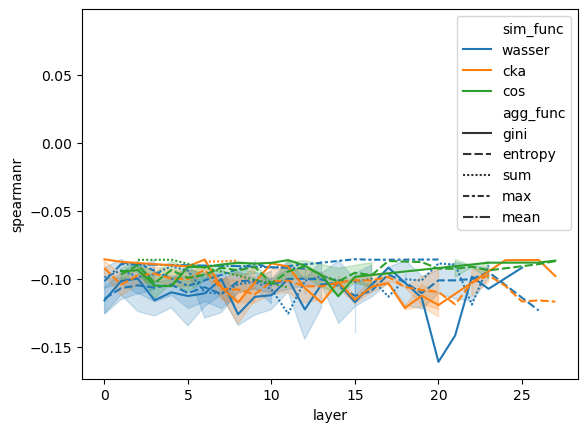

In [10]:
import seaborn as sns

sns.lineplot(
    data=sig,
    x="layer",
    y="spearmanr",
    hue="sim_func",
    style="agg_func"
)


In [11]:
sig.groupby("sim_func")["spearmanr"].mean().sort_values()


sim_func
wasser   -0.105050
cka      -0.102393
cos      -0.092489
Name: spearmanr, dtype: float64

## Per-model, per layer HEATMAP (1 layer = 1 subplot)

In [12]:
model_map = {
    "google-bert/bert-base-uncased": "BERT-base Uncased",
    "google-bert/bert-base-cased": "BERT-base Cased",
    "google-bert/bert-large-uncased": "BERT-large Uncased",
    "google-bert/bert-large-cased": "BERT-large Cased",
    "answerdotai/ModernBERT-base": "ModernBERT-base",
    "answerdotai/ModernBERT-large": "ModernBERT-large",
}

sig["model_clean"] = sig["model_name"].map(model_map)

/var/folders/75/bf_qltnx6nq0w79rv4cx0ttc0000gn/T/ipykernel_6988/1945223216.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sig["model_clean"] = sig["model_name"].map(model_map)


In [13]:
# import math
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns



# # ---- adapt these column names to your df ----
# MODEL_COL = "model_clean"
# CORR_COL  = "spearmanr"
# PVAL_COL  = "p_value"
# LAYER_COL = "layer"

# # combine similarity + aggregation into one column
# sig["condition"] = sig["sim_func"].astype(str) + "-" + sig["agg_func"].astype(str)

# # optional: ensure stable ordering
# models = list(sig[MODEL_COL].dropna().unique())
# layers = sorted(sig[LAYER_COL].dropna().unique(), key=lambda x: (isinstance(x, str), x))
# conditions = sorted(sig["condition"].dropna().unique())

# # ---- one figure per model; subplots = layers ----
# for model in models:
#     d = sig[sig[MODEL_COL] == model].copy()

#     # decide subplot grid
#     n_layers = len(layers)
#     ncols = min(4, n_layers)                 # tweak as you like
#     nrows = math.ceil(n_layers / ncols)

#     fig, axes = plt.subplots(
#         nrows=nrows, ncols=ncols,
#         figsize=(4.2 * ncols, 3.2 * nrows),
#         squeeze=False
#     )

#     # compute global color limits for this model so all layer panels are comparable
#     vmin = d[CORR_COL].min()
#     vmax = d[CORR_COL].max()
#     lim = max(abs(vmin), abs(vmax)) if np.isfinite([vmin, vmax]).all() else 1.0

#     for i, layer in enumerate(layers):
#         ax = axes[i // ncols, i % ncols]
#         dl = d[d[LAYER_COL] == layer].copy()

#         # pivot for heatmap (rows = model, cols = condition)
#         heatmap_data = (
#             dl.pivot(index=MODEL_COL, columns="condition", values=CORR_COL)
#               .reindex(index=[model], columns=conditions)
#         )

#         # pivot p-values for significance masking
#         pvals = (
#             dl.pivot(index=MODEL_COL, columns="condition", values=PVAL_COL)
#               .reindex(index=[model], columns=conditions)
#         )
#         significant = pvals < 0.05

#         # draw heatmap
#         sns.heatmap(
#             heatmap_data,
#             ax=ax,
#             annot=True,
#             fmt=".3f",
#             cmap="coolwarm",
#             center=0,
#             vmin=-lim, vmax=lim,                 # consistent scale across layers
#             linewidths=0.5,
#             cbar=(i == 0),                       # single colorbar for the whole figure
#             cbar_kws={"label": "Correlation"} if i == 0 else None
#         )

#         # overlay significance markers (•)
#         for y in range(significant.shape[0]):
#             for x in range(significant.shape[1]):
#                 if bool(significant.iloc[y, x]):
#                     ax.text(
#                         x + 0.88, y + 0.5, "•",
#                         ha="center", va="center",
#                         color="black", fontsize=14
#                     )

#         ax.set_title(f"Layer {layer}")
#         ax.set_xlabel("Similarity Function – Aggregation Metric")
#         ax.set_ylabel("")  # only one row, so y-label is redundant

#         # If you want the model name shown on the y tick:
#         # ax.set_yticklabels([model], rotation=0)

#     # turn off any unused axes
#     for j in range(n_layers, nrows * ncols):
#         axes[j // ncols, j % ncols].axis("off")

#     fig.suptitle(f"{model}: Correlation heatmaps by layer (• p < 0.05)", y=1.02)
#     fig.tight_layout()

#     outpath = f"visualisation/plots/{model}_heatmaps_by_layer.pdf"
#     fig.savefig(outpath, dpi=300, bbox_inches="tight", format="pdf")
#     plt.close(fig)


In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# sig["model_clean"] = sig["model_name"].map(model_map)


MODEL_COL = "model_clean"
CORR_COL  = "spearmanr"
PVAL_COL  = "p_value"
LAYER_COL = "layer"

sig["condition"] = sig["sim_func"].astype(str) + "-" + sig["agg_func"].astype(str)

models = list(sig[MODEL_COL].dropna().unique())
# layers = sorted(sig[LAYER_COL].dropna().unique())
conditions = sorted(sig["condition"].dropna().unique())


for model in models:
    d = sig[sig[MODEL_COL] == model].copy()

    layers = sorted(d[LAYER_COL].dropna().unique())

    n_layers = len(d[LAYER_COL].unique())
    ncols = min(4, n_layers)
    nrows = math.ceil(n_layers / ncols)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(4.2 * ncols, 3.2 * nrows),
        squeeze=False
    )

    # ---- shared normalization across all subplots ----
    vmin = d[CORR_COL].min()
    vmax = d[CORR_COL].max()
    lim = max(abs(vmin), abs(vmax))
    norm = mpl.colors.Normalize(vmin=-lim, vmax=lim)
    cmap = plt.get_cmap("coolwarm")

    for i, layer in enumerate(layers):
        ax = axes[i // ncols, i % ncols]
        dl = d[d[LAYER_COL] == layer]

        heatmap_data = (
            dl.pivot(index=MODEL_COL, columns="condition", values=CORR_COL)
              .reindex(index=[model], columns=conditions)
        )

        pvals = (
            dl.pivot(index=MODEL_COL, columns="condition", values=PVAL_COL)
              .reindex(index=[model], columns=conditions)
        )
        significant = pvals < 0.05

        sns.heatmap(
            heatmap_data,
            ax=ax,
            annot=True,
            fmt=".3f",
            cmap=cmap,
            norm=norm,
            linewidths=0.5,
            cbar=False,        # ← important
        )

        # significance dots
        for y in range(significant.shape[0]):
            for x in range(significant.shape[1]):
                if significant.iloc[y, x]:
                    ax.text(
                        x + 0.88,
                        y + 0.5,
                        "•",
                        ha="center",
                        va="center",
                        color="black",
                        fontsize=14
                    )

        ax.set_title(f"Layer {layer}")
        ax.set_xlabel("Similarity Function – Aggregation Metric")
        ax.set_ylabel("")
        ax.set_yticklabels([model], rotation=0)

    # turn off unused axes
    for j in range(n_layers, nrows * ncols):
        axes[j // ncols, j % ncols].axis("off")

    # ---- add a figure-level colorbar at the TOP ----
    cax = fig.add_axes([0.15, 0.935, 0.7, 0.015])  # [left, bottom, width, height]
    cb = mpl.colorbar.ColorbarBase(
        cax,
        cmap=cmap,
        norm=norm,
        orientation="horizontal"
    )
    cb.set_label("Correlation", labelpad=5)
    cb.ax.xaxis.set_label_position("top")
    cb.ax.xaxis.tick_top()

    # fig.suptitle(
    #     f"{model}: Correlation heatmaps by layer (• p < 0.05)",
    #     y=0.99
    # )

    fig.tight_layout(rect=[0, 0, 1, 0.90])  # leave space for colorbar + title

    fig.savefig(
        f"visualisation/plots/{model}_heatmaps_by_layer.pdf",
        dpi=300,
        bbox_inches="tight",
        format="pdf"
    )
    plt.close(fig)

    


/var/folders/75/bf_qltnx6nq0w79rv4cx0ttc0000gn/T/ipykernel_6988/3572614908.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sig["condition"] = sig["sim_func"].astype(str) + "-" + sig["agg_func"].astype(str)
/var/folders/75/bf_qltnx6nq0w79rv4cx0ttc0000gn/T/ipykernel_6988/3572614908.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.90])  # leave space for colorbar + title
/var/folders/75/bf_qltnx6nq0w79rv4cx0ttc0000gn/T/ipykernel_6988/3572614908.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.90])  # leave space for colorbar + title

In [15]:
sig[sig[MODEL_COL] == "ModernBERT-base"].layer.unique() # 16, 19 missing


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 17,
       18, 20])

## counts

Bigger models are better at producing significant results. 

In [16]:
model_counts = sig['model_name'].value_counts()
model_counts

model_name
google-bert/bert-large-cased      115
google-bert/bert-large-uncased     91
answerdotai/ModernBERT-large       66
google-bert/bert-base-uncased      61
google-bert/bert-base-cased        58
answerdotai/ModernBERT-base        52
Name: count, dtype: int64

Wasser-entropy seems to be the best at producing the most significant results

In [17]:
condition_counts = sig['condition'].value_counts()
condition_counts

condition
wasser-entropy    101
cka-entropy        82
cos-entropy        68
wasser-gini        62
wasser-sum         51
cka-gini           37
cos-gini           21
wasser-max         10
wasser-mean         4
cos-sum             3
cka-sum             3
cos-mean            1
Name: count, dtype: int64

In [18]:
layer_counts = sig['layer'].value_counts()
layer_counts

layer
1     30
9     28
2     26
3     25
7     25
0     23
6     23
8     23
10    23
4     22
5     22
11    20
15    17
12    15
20    14
19    12
14    12
13    12
17    11
16    11
22    10
23    10
18     8
21     8
26     5
27     4
24     2
25     2
Name: count, dtype: int64

## Correlation: decomp vs human decomp (90 idioms)

In [ ]:
# bulkes = pd.read_csv("data/bulkes/13428_2016_747_MOESM1_ESM 2/GLOBAL DECOMPOSABILITY-Table 1.csv")

# overlaps_df = pd.read_csv("data/processed/bulkes_impli_overlaps.csv")


# overlap_idioms_bulkes = overlaps_df.bulkes.tolist()
# print(f"Number of overlapping idioms: {len(overlap_idioms_bulkes)}")
# print(f"Number of unique overlapping idioms: {len(set(overlap_idioms_bulkes))}")

# from collections import Counter
# repeated = [item for item, count in Counter(overlap_idioms_bulkes).items() if count > 1]
# print(repeated)

# # overlap_idioms_bulkes

# matched_rows = bulkes[bulkes['idiom'].isin(overlap_idioms_bulkes)]


# print(matched_rows.shape)


# human_decomp = overlaps_df.merge(
#     bulkes,
#     left_on="bulkes",
#     right_on="idiom",
#     how="inner"   # or "left", "right", "outer"
# )

# human_decomp = human_decomp[["impli", "bulkes","PROPORTION RATED AS DECOMPOSABLE (%)",]]

# human_decomp.head()

# human_decomp.to_csv("data/processed/bulkes_impli_human_decomp.csv", index=False)

In [ ]:
df_human_decomp = pd.read_csv("data/processed/bulkes_impli_human_decomp.csv")


In [21]:

with_bulkes = df.merge(
    df_human_decomp,
    left_on="base_form",
    right_on="impli",
    how="inner"   # or "left", "right", "outer"
)

print(with_bulkes.shape)
print(with_bulkes.columns)
with_bulkes.head()



(247050, 21)
Index(['Unnamed: 0', 'premise', 'hypothesis', 'extracted_idiom', 'base_form',
       'idiom_pos', 'idiom_processed', 'token_scores', 'decomp_score',
       'sim_function', 'model_name', 'model_label', 'model_folder',
       'timestamp', 'layer', 'sim_func', 'agg_func', 'source_path', 'impli',
       'bulkes', 'PROPORTION RATED AS DECOMPOSABLE (%)'],
      dtype='object')


,Unnamed: 0,premise,hypothesis,extracted_idiom,base_form,idiom_pos,idiom_processed,token_scores,decomp_score,sim_function,...,model_label,model_folder,timestamp,layer,sim_func,agg_func,source_path,impli,bulkes,PROPORTION RATED AS DECOMPOSABLE (%)
0,1,"And then , the Daily Telegraph discovered ‘ th...","And then , the Daily Telegraph discovered ‘ th...",against the grain,against the grain,"[against, the, grain]",against the grain,"[(25, 'against', 0.015303194522857666), (26, '...",0.015303,cos,...,BERT-base Uncased,google-bert_bert-base-uncased,2025-12-25_02:34:13,0,cos,max,/Users/mmi/Documents/projects/idioms_decomposa...,against the grain,Go against the grain,0.4443
1,3,The imagination trembles at some of these idea...,The imagination trembles at some of these idea...,come clean,come clean,"[come, clean]",come clean,"[(19, 'come', 0.0060558319091796875), (20, 'cl...",0.006056,cos,...,BERT-base Uncased,google-bert_bert-base-uncased,2025-12-25_02:34:13,0,cos,max,/Users/mmi/Documents/projects/idioms_decomposa...,come clean,Come clean,0.4964
2,5,"All her insecurities surged painfully as , thr...","All her insecurities surged painfully as , reg...",throwing caution to the winds,throw caution to the wind,"[throw, caution, to, the, wind]",throwing caution to the winds,"[(10, 'throwing', 0.004351675510406494), (11, ...",0.008592,cos,...,BERT-base Uncased,google-bert_bert-base-uncased,2025-12-25_02:34:13,0,cos,max,/Users/mmi/Documents/projects/idioms_decomposa...,throw caution to the wind,Throw caution to the wind,0.3714
3,7,‘ It breaks my heart that his career has been ...,‘ It overwhelms me that his career has been ru...,breaks my heart,break someone's heart,"[break, someone, 's, heart]",breaks my heart,"[(3, 'breaks', -0.01068788766860962), (4, 'my'...",0.010688,cos,...,BERT-base Uncased,google-bert_bert-base-uncased,2025-12-25_02:34:13,0,cos,max,/Users/mmi/Documents/projects/idioms_decomposa...,break someone's heart,Break someone's heart,0.6421
4,8,For me it is quite out of the question that th...,For me it is impossible that the Maastricht tr...,out of the question,out of the question,"[out, of, the, question]",out of the question,"[(6, 'out', 0.01086956262588501), (7, 'of', 0....",0.012036,cos,...,BERT-base Uncased,google-bert_bert-base-uncased,2025-12-25_02:34:13,0,cos,max,/Users/mmi/Documents/projects/idioms_decomposa...,out of the question,Be out of the question,0.6849


In [22]:
def run_correlation_df(
    df,
    x_col="entropy_full",
    y_col="decomp_score"
):
    # drop NaNs just in case
    sub = df[[x_col, y_col]].dropna()

    if len(sub) < 3:
        return None

    corr, p_value = spearmanr(sub[x_col], sub[y_col])

    return {
        "spearmanr": corr,
        "p_value": p_value,
        "n": len(sub),
    }


group_cols = [
    "model_name",
    "layer",
    "sim_func",
    "agg_func",
    "timestamp",
]

results = []

for keys, group in with_bulkes.groupby(group_cols):
    stats = run_correlation_df(group, x_col="decomp_score", y_col="PROPORTION RATED AS DECOMPOSABLE (%)")

    if stats is None:
        continue

    record = dict(zip(group_cols, keys))
    record.update(stats)
    results.append(record)

human_decomp_corr = pd.DataFrame(results)


print(human_decomp_corr.shape)
human_decomp_corr.head()




(1830, 8)


,model_name,layer,sim_func,agg_func,timestamp,spearmanr,p_value,n
0,answerdotai/ModernBERT-base,0,cka,entropy,2025-12-25_02:34:31,0.092846,0.284143,135
1,answerdotai/ModernBERT-base,0,cka,gini,2025-12-25_02:34:31,0.085790,0.322496,135
2,answerdotai/ModernBERT-base,0,cka,max,2025-12-25_02:34:31,-0.005983,0.945091,135
3,answerdotai/ModernBERT-base,0,cka,mean,2025-12-25_02:34:31,-0.012742,0.883385,135
4,answerdotai/ModernBERT-base,0,cka,sum,2025-12-25_02:34:31,0.009922,0.909064,135


In [23]:
decomp_human_sig = human_decomp_corr[human_decomp_corr["p_value"] < 0.05]

decomp_human_sig.sort_values("spearmanr", ascending=False, inplace=True)

print(decomp_human_sig.shape)
decomp_human_sig.head(30)

(34, 8)


/var/folders/75/bf_qltnx6nq0w79rv4cx0ttc0000gn/T/ipykernel_6988/2169486243.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  decomp_human_sig.sort_values("spearmanr", ascending=False, inplace=True)


,model_name,layer,sim_func,agg_func,timestamp,spearmanr,p_value,n
1829,google-bert/bert-large-uncased,23,wasser,sum,2025-12-25_02:34:13,0.241241,0.004822,135
139,answerdotai/ModernBERT-base,9,cka,sum,2025-12-25_02:34:31,0.234678,0.006149,135
137,answerdotai/ModernBERT-base,9,cka,max,2025-12-25_02:34:31,0.221445,0.009847,135
138,answerdotai/ModernBERT-base,9,cka,mean,2025-12-25_02:34:31,0.220689,0.010108,135
124,answerdotai/ModernBERT-base,8,cka,sum,2025-12-25_02:34:31,0.218984,0.010718,135
109,answerdotai/ModernBERT-base,7,cka,sum,2025-12-25_02:34:31,0.218516,0.010891,135
1456,google-bert/bert-large-cased,23,cka,gini,2025-12-25_02:34:13,0.212328,0.013423,135
108,answerdotai/ModernBERT-base,7,cka,mean,2025-12-25_02:34:31,0.209640,0.014674,135
261,answerdotai/ModernBERT-base,17,cos,gini,2025-12-25_02:34:31,0.207764,0.015606,135
123,answerdotai/ModernBERT-base,8,cka,mean,2025-12-25_02:34:31,0.206566,0.016228,135


In [28]:
decomp_human_sig["model_name"].value_counts()

model_name
answerdotai/ModernBERT-base       22
google-bert/bert-large-cased       5
google-bert/bert-large-uncased     4
answerdotai/ModernBERT-large       2
google-bert/bert-base-cased        1
Name: count, dtype: int64

### corr(human decomp, syntactic flexibility)

In [ ]:
# print(merged.columns)
# print(merged.shape)
# print(with_bulkes.columns)
# print(with_bulkes.shape)

# merged.head()
with_bulkes.head()

df_sytax = pd.read_csv("data/processed/checked_manual_e_w_cql.csv")

df_syntax.head()

print(df_syntax.shape)
print(df_syntax.columns)

(527, 29)
Index(['Unnamed: 0', 'premise', 'hypothesis', 'extracted_idiom', 'base_form',
       'idiom_pos', 'identity_cql', 'passive_cql', 'adj_insertion_cql_1',
       'adj_insertion_cql_2', 'adv_insertion_cql', 'adv_insertion_cql_adj',
       'nominalization_cql', 'adj_insertion_full_1', 'adj_insertion_full_2',
       'adj_insertion_rel_1', 'adj_insertion_rel_2', 'adv_insertion_full',
       'adv_insertion_full_adj', 'adv_insertion_rel', 'adv_insertion_rel_adj',
       'identity_full', 'identity_rel', 'nominalization_full',
       'nominalization_rel', 'passive_full', 'passive_rel', 'entropy_full',
       'entropy_rel'],
      dtype='object')


In [25]:
column_to_merge = "premise"

with_bulkes_syntax = with_bulkes.merge(
    df_syntax,
    how="left",
    on=column_to_merge,   # same column name on both sides
)

with_bulkes_syntax.shape
print(with_bulkes_syntax.columns)

with_bulkes_syntax.head()


Index(['Unnamed: 0_x', 'premise', 'hypothesis_x', 'extracted_idiom_x',
       'base_form_x', 'idiom_pos_x', 'idiom_processed', 'token_scores',
       'decomp_score', 'sim_function', 'model_name', 'model_label',
       'model_folder', 'timestamp', 'layer', 'sim_func', 'agg_func',
       'source_path', 'impli', 'bulkes',
       'PROPORTION RATED AS DECOMPOSABLE (%)', 'Unnamed: 0_y', 'hypothesis_y',
       'extracted_idiom_y', 'base_form_y', 'idiom_pos_y', 'identity_cql',
       'passive_cql', 'adj_insertion_cql_1', 'adj_insertion_cql_2',
       'adv_insertion_cql', 'adv_insertion_cql_adj', 'nominalization_cql',
       'adj_insertion_full_1', 'adj_insertion_full_2', 'adj_insertion_rel_1',
       'adj_insertion_rel_2', 'adv_insertion_full', 'adv_insertion_full_adj',
       'adv_insertion_rel', 'adv_insertion_rel_adj', 'identity_full',
       'identity_rel', 'nominalization_full', 'nominalization_rel',
       'passive_full', 'passive_rel', 'entropy_full', 'entropy_rel'],
      dtype='object

,Unnamed: 0_x,premise,hypothesis_x,extracted_idiom_x,base_form_x,idiom_pos_x,idiom_processed,token_scores,decomp_score,sim_function,...,adv_insertion_rel,adv_insertion_rel_adj,identity_full,identity_rel,nominalization_full,nominalization_rel,passive_full,passive_rel,entropy_full,entropy_rel
0,1,"And then , the Daily Telegraph discovered ‘ th...","And then , the Daily Telegraph discovered ‘ th...",against the grain,against the grain,"[against, the, grain]",against the grain,"[(25, 'against', 0.015303194522857666), (26, '...",0.015303,cos,...,0.03,0.00,26812.0,0.44,0.0,0.0,0.0,0.00,0.367395,0.398219
1,3,The imagination trembles at some of these idea...,The imagination trembles at some of these idea...,come clean,come clean,"[come, clean]",come clean,"[(19, 'come', 0.0060558319091796875), (20, 'cl...",0.006056,cos,...,0.09,0.21,36858.0,0.60,NaN,NaN,0.0,0.00,0.838594,0.840136
2,5,"All her insecurities surged painfully as , thr...","All her insecurities surged painfully as , reg...",throwing caution to the winds,throw caution to the wind,"[throw, caution, to, the, wind]",throwing caution to the winds,"[(10, 'throwing', 0.004351675510406494), (11, ...",0.008592,cos,...,0.02,0.00,9541.0,0.15,NaN,NaN,152.0,0.00,0.462774,0.362211
3,7,‘ It breaks my heart that his career has been ...,‘ It overwhelms me that his career has been ru...,breaks my heart,break someone's heart,"[break, someone, 's, heart]",breaks my heart,"[(3, 'breaks', -0.01068788766860962), (4, 'my'...",0.010688,cos,...,0.21,0.00,84758.0,1.38,15.0,0.0,13526.0,0.22,0.784594,0.784530
4,8,For me it is quite out of the question that th...,For me it is impossible that the Maastricht tr...,out of the question,out of the question,"[out, of, the, question]",out of the question,"[(6, 'out', 0.01086956262588501), (7, 'of', 0....",0.012036,cos,...,0.41,0.00,73419.0,1.19,0.0,0.0,0.0,0.00,0.582731,0.569098


In [26]:
group_cols = [
    "model_name",
    "layer",
    "sim_func",
    "agg_func",
    "timestamp",
]

results = []

for keys, group in with_bulkes_syntax.groupby(group_cols):
    stats = run_correlation_df(group, x_col="PROPORTION RATED AS DECOMPOSABLE (%)", y_col="entropy_full")

    if stats is None:
        continue

    record = dict(zip(group_cols, keys))
    record.update(stats)
    results.append(record)



human_decomp_syntax_corr = pd.DataFrame(results)


print(human_decomp_syntax_corr.shape)
human_decomp_syntax_corr.head()


# human_decomp_syntax_sig = human_decomp_syntax_corr[human_decomp_syntax_corr["p_value"] < 0.05]

# human_decomp_syntax_sig.head()


(1830, 8)


,model_name,layer,sim_func,agg_func,timestamp,spearmanr,p_value,n
0,answerdotai/ModernBERT-base,0,cka,entropy,2025-12-25_02:34:31,0.007172,0.934205,135
1,answerdotai/ModernBERT-base,0,cka,gini,2025-12-25_02:34:31,0.007172,0.934205,135
2,answerdotai/ModernBERT-base,0,cka,max,2025-12-25_02:34:31,0.007172,0.934205,135
3,answerdotai/ModernBERT-base,0,cka,mean,2025-12-25_02:34:31,0.007172,0.934205,135
4,answerdotai/ModernBERT-base,0,cka,sum,2025-12-25_02:34:31,0.007172,0.934205,135
